In [49]:
%load_ext autoreload
%autoreload 2
    
# Import some libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from scipy.special import erfc
import sympy as sym

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
# Object parameters
epsilon=0.
sigma=3.5e6 # Conductivity in S/m
mu0=4*np.pi*1e-7
mu=4*mu0
mur=mu/mu0
alpha=0.01 # Object radius in m
# Note how the accuracy of the expansion DRSF expansion depends on beta = np.sqrt(sigma*mu)*alpha as well as frequencies 
# Number of frequencies
N=3000
#Omega=np.logspace(-2,11,N)
Omega=np.logspace(-3,12,N)
#Omega=np.logspace(-4,13,N)


# Number of poles in exact expansion
Npoles=N#150
scaleon=False # False (turn on/off scaling when computed DRSF)

In [51]:
# Exact sphere Frequency Domain
def exact_sphere(alpha, epsilon, mur, sigma, omega):
    """
    Function to calculate the mpt for a sphere of radius alpha at radial frequency omega.
    Addapted from a Matlab function from Paul Ledger (exactsphererev5freqscan_nod.m).
    :param omega - Angular frequency rad/s
    :param epsilon - Permittivity:
    :param sigma - Conductivity S/m:
    :param mur - Relative Permeability:
    :param alpha - Sphere radius m:
    :return eig - Single unique eigenvalue of the mpt tensor for a sphere of radius alpha:
    """

    mu0 = 4 * np.pi * (1e-7)
    mu = mur * mu0
    k = np.sqrt((omega ** 2 * epsilon * sigma) + (mu * sigma * omega) * 1j)

    # Using sympy to try to avoid overflow errors.
    k *= alpha
    alpha = alpha

    js_0_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(1 / 2, k)
    js_1_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(3 / 2, k)
    js_2_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(5 / 2, k)
    mpt = (2 * np.pi * alpha ** 3) * (2 * (mu - mu0) * js_0_kr + (2 * mu + mu0) * js_2_kr) / (
        (mu + 2 * mu0) * js_0_kr + (mu - mu0) * js_2_kr)
    return complex(mpt.evalf())


In [52]:
# Exact Step Function Response from a conducting non-permable sphere 
from scipy.optimize import fsolve
def derf(z):
    return 2/np.sqrt(np.pi)*np.exp(-z**2)
# Response from a step function
def exactA(t,sigma,mu,alpha,Npoles):
    mu0 = 4 * np.pi * (1e-7)
    mur=mu/mu0
    beta=np.sqrt(sigma*mu)*alpha
    x=np.sqrt(t)/beta
    T=t/beta**2
    # This is only valid for mur=1
    # Equation (11) Wait + Spies
    #A1=3*(T+1/3-2*np.sqrt(T/np.pi))
    # Method 1
    #for n in range(1,Npoles):
    #    derfn=derf(n/np.sqrt(T))
    #    erfcn=erfc(n/np.sqrt(T))
    #    A1+=-3*2*n*(np.sqrt(T)/n*derfn-2*erfcn)
    # Method 2 (not valid for small T)
    #A2=0.
    #for n in range(1,Npoles):
    #    A2+=6/np.pi**2*np.exp(-np.pi**2*n**2*T)/n**2 # eqn (22) Wait + Spies
    #   find solutions to fzerofun(deltan,mur) =0 

    # Only Method 2 works for permable case
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    A2=-2*(mur-1)/(mur+2)
    for n in range(1,Npoles):
        deltan2=Deltan[n-1]**2
        A2+=6*mur/((mur+2)*(mur-1)+ deltan2)*np.exp(-deltan2*T) # eqn (18) Wait + Spies
    A1=A2
    return A1,A2


# Response from a impulse function
def exactB(t,sigma,mu,alpha,Npoles):
    beta=np.sqrt(sigma*mu)*alpha
    x=np.sqrt(t)/beta
    T=t/beta**2
    # Only Method 2 works for permable case
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    B2=0.
    for n in range(1,Npoles):
        deltan2=Deltan[n-1]**2
        B2+=-6*mur/((mur+2)*(mur-1)+ deltan2)*deltan2*np.exp(-deltan2*T) # eqn (21) Wait + Spies
    B1=B2
    return B1,B2    

# Exact poles, amp for conducting permable sphere
def exactpoleres(sigma,mu,alpha,N):
    poles=np.zeros((N))
    amp=np.zeros((N))
    beta=np.sqrt(sigma*mu)*alpha
    mur=mu/mu0

#   find solutions to fzerofun(deltan,mur) =0 
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    #print(Deltan)
    for n in range(1,N):
        # This is for mu=mu_0
        #deltan2=np.pi**2*n**2
        # This is for general mu
        deltan2=Deltan[n-1]**2
        poles[n]=-deltan2/beta**2
        # This is for mu =mu_0
        #amp[n]=6./(deltan2)
        # For general mu
        amp[n] = 6*mur/((mur+2)*(mur-1)+deltan2)
    return poles,amp

# Residual function to help find solutions to ((mur-1)+deltan2)*(tan deltan ) - (mur-1)*deltan = 0
def fzerofun(deltan,mur):
    return ((mur-1)+deltan**2)*np.tan(deltan) - (mur-1)*deltan

1.999737284434438


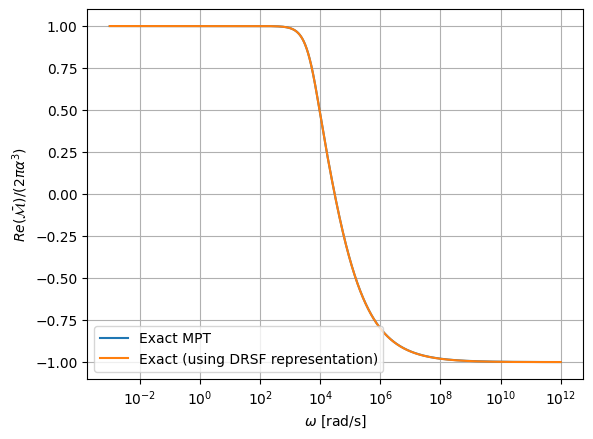

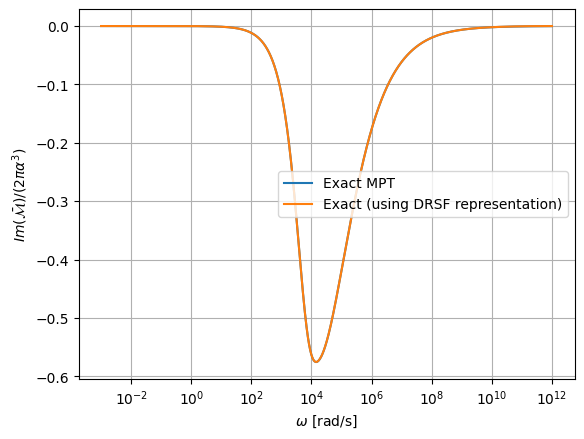

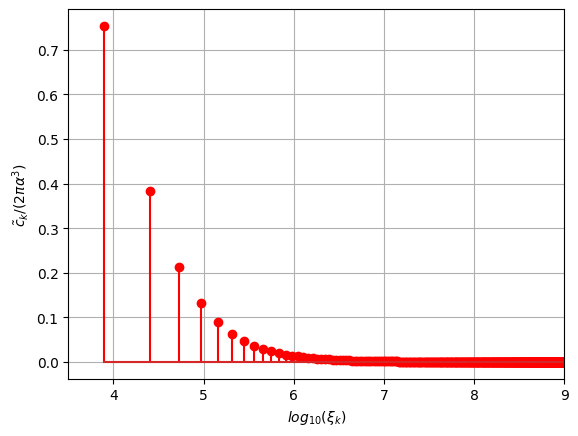

In [53]:
# Evaluate exact solution
MPT=np.zeros((N),dtype=complex)
for n in range(N):
    MPT[n]=np.conj(exact_sphere(alpha, epsilon, mur, sigma, Omega[n]))/(2*np.pi*alpha**3)
# Note scaled by 1/(2pi alpha^3)
    
# Compute exact poles and ck
exactpoles,exactamp=exactpoleres(sigma,mu,alpha,Npoles)

sum=0
for n in range(Npoles):
    sum+=exactamp[n]
print(sum)

# Baum (8.1) M(s) = M(inf) + sum amp/ (s -salpha)
DRSF=np.real(MPT[-1])*np.ones((N),dtype=complex)
for i in range(1,Npoles):
    DRSF+=exactamp[i]/(1-1j*Omega/exactpoles[i])

plt.semilogx(Omega,np.real(MPT),label="Exact MPT")
plt.semilogx(Omega,np.real(DRSF),label="Exact (using DRSF representation)")
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M}) /(2\pi\alpha^3)$")
plt.legend()
plt.grid()
#plt.savefig("results/sphere/realmpt_exact_rep.pdf")
plt.show()

plt.figure()
plt.semilogx(Omega,np.imag(MPT),label="Exact MPT")
plt.semilogx(Omega,np.imag(DRSF),label="Exact (using DRSF representation)")
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M}) /(2\pi\alpha^3)$")
plt.legend()
plt.grid()
#plt.savefig("results/sphere/imagmpt_exact_rep.pdf")
plt.show()

col=['r','b','x']
plt.figure()
plt.stem(np.log10(np.abs(exactpoles[1:])), exactamp[1:],col[0])
#plt.setp(plt.gca().lines, markersize=0)
plt.xlabel(r'$log_{10}(\xi_k)$')
plt.ylabel(r'$\tilde{c}_k/(2\pi\alpha^3)$')
plt.xlim(3.5,9)
plt.grid()
#plt.savefig("results/sphere/modesamp_exact_rep.pdf")

plt.show()




In [54]:
from Functions.Core_Spectrum.getimpulse_step import *
#from getimpulse_step_iter import *
#from getimpulse_step_test import *


# Call Python function to get Transiant Response for all Tensor Coefficients
Tensors=np.zeros((N,9),dtype=complex)
for n in range(N):
    Tensors[n,0]=MPT[n]
    Tensors[n,4]=MPT[n]
    Tensors[n,8]=MPT[n]


MPTinf=MPT[-1].ravel()*np.eye(3)*2*np.pi*alpha**3
MPTinf=-np.eye(3)*2*np.pi*alpha**3
Tensors=Tensors*2*np.pi*alpha**3

N0=MPT[0].ravel()*np.eye(3)

Frequencies=Omega
#time=np.logspace(-10,-1,N)
time=np.logspace(-6,-1,N)
Poles, Amp, Nfound = PolesandAmp(Frequencies,Tensors,MPTinf, Iterative_refine=False)
Sgn_impulse, Sgn_step = getimpulse_step(MPTinf,N0,time, Poles, Amp, Nfound)
##Poles, Amp, Nfound, Sgn_impulse, Sgn_step = getimpulse_step_iter(Frequencies,Tensors,MPTinf,N0,time)
#Poles, Amp, Nfound, Sgn_impulse, Sgn_step = getimpulse_step_test(Frequencies,Tensors,MPTinf,N0,time)



[-6.28318531e-06 -6.28318531e-06 -6.28318531e-06]
NNLS Solution residual 1.3186326312315427e-07
Found32terms
c=[-6.28257583e-06  4.72928196e-06  2.40883107e-06  1.35452011e-06
  8.89124526e-07  6.78247957e-07  5.40675046e-07  4.26818074e-07
  3.33486257e-07  2.59730115e-07  2.02082682e-07  1.57434521e-07
  1.22740816e-07  9.54082954e-08  7.30316984e-08  5.21125593e-08
  3.78732856e-08  3.79599498e-08  3.47391649e-08  2.90213573e-08
  2.35779891e-08  1.89113206e-08  1.50249277e-08  1.18271206e-08
  9.20772010e-09  7.08866633e-09  5.38072307e-09  4.01787249e-09
  2.94101299e-09  2.10238658e-09  1.46598760e-09  1.09596891e-09]
xi=[0.00000000e+00 7.89294870e+03 2.53800115e+04 5.38039439e+04
 9.51310660e+04 1.57563174e+05 2.58704670e+05 4.25077866e+05
 6.96987753e+05 1.13798729e+06 1.84856544e+06 2.98633880e+06
 4.79637593e+06 7.64751910e+06 1.20403361e+07 1.83409210e+07
 2.61989827e+07 3.78596779e+07 5.88273677e+07 9.52049552e+07
 1.58005720e+08 2.68318702e+08 4.67000482e+08 8.35863314e+08

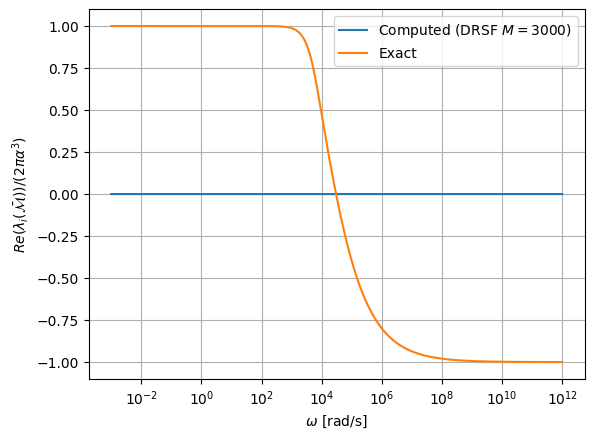

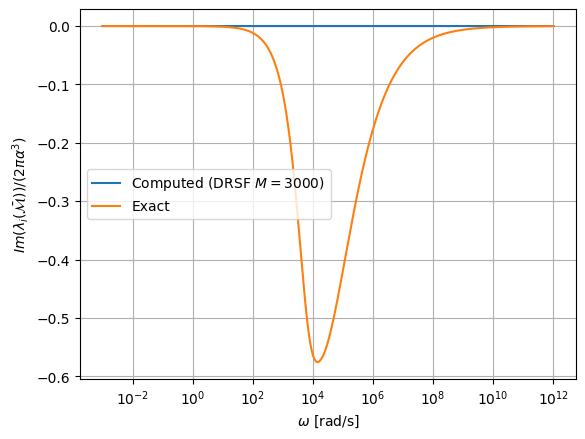

In [55]:
# xi_k > 0 and c_k > 0 by construction of above algorithm
for i in range(1):
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSF=MPTinf[i,i]*np.ones((N),dtype=complex)
    nfound=Nfound[i]
    ck=Amp[0:nfound,i]
    xi=Poles[0:nfound,i]
    DRSF=(ck[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        DRSF+=ck[n]/(1+1j*Omega/xi[n])
    plt.figure(1)
    plt.semilogx(Omega,np.real(DRSF),label="Computed (DRSF $M=$"+str(N)+")")
    plt.figure(2)
    plt.semilogx(Omega,np.imag(DRSF),label="Computed (DRSF $M=$"+str(N)+")")

plt.figure(1)
plt.semilogx(Omega,np.real(MPT),label="Exact")
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\lambda_i(\bar{\cal M}))/(2 \pi \alpha^3)$")
plt.legend()
plt.grid()
#plt.savefig("results/sphere/computed_realmpt_M"+str(N)+".pdf")

plt.figure(2)
plt.semilogx(Omega,np.imag(MPT),label="Exact")
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\lambda_i(\bar{\cal M}))/(2 \pi \alpha^3) $")

plt.legend()
plt.grid()
#plt.savefig("results/sphere/computed_imagmpt_M"+str(N)+".pdf")
plt.show()



32
1.256576114424179e-05


<Figure size 640x480 with 0 Axes>

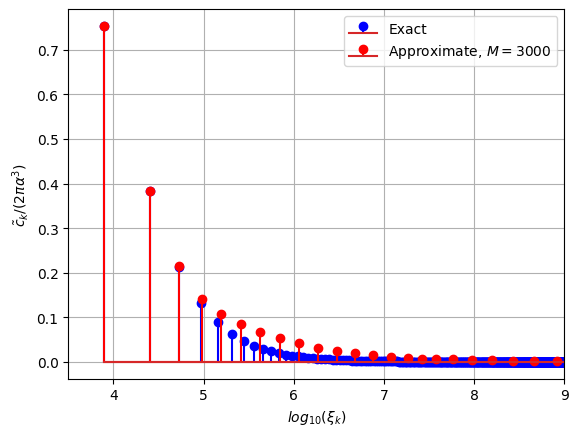

In [56]:
# Compare the modes and amplitudes
plt.figure()
col=['r','b','x']
for i in range(1):
    plt.figure()
    nfound=Nfound[i]
    ck=Amp[0:nfound,i]
    xi=Poles[0:nfound,i]
    print(nfound)
    sum=0.
    for n in range(1,nfound):
        sum+=ck[n]
    print(sum)
    plt.stem(np.log10(np.abs(exactpoles[1:])), exactamp[1:],col[1],label="Exact")
    plt.stem(np.log10(np.abs(xi[1:])), ck[1:]/(2*np.pi*alpha**3),col[0],label=r"Approximate, $M=$"+str(N))
    #plt.stem(np.log10(np.abs(xi[1:])), ck[1:],col[0],label=r"Approximate, $M=$"+str(N))

    plt.xlabel(r'$log_{10}(\xi_k)$')
    plt.ylabel(r'$\tilde{c}_k/(2\pi \alpha^3)$')
    plt.xlim(3.5,9)
    plt.legend()
    plt.grid()
    #plt.savefig("results/sphere/amp_modes_ev_M"+str(N)+".pdf")
plt.show()

In [57]:
# Fix Frequencies for evaluation P=100
P=100
OmegaOut=np.logspace(-3,12,P)

# Evaluate exact solution
MPTout=np.zeros((P),dtype=complex)
for n in range(P):
    MPTout[n]=np.conj(exact_sphere(alpha, epsilon, mur, sigma, OmegaOut[n]))/(2*np.pi*alpha**3)

for i in range(1):
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSF=MPTinf[i,i]*np.ones((N),dtype=complex)
    nfound=Nfound[i]
    ck=Amp[0:nfound,i]
    xi=Poles[0:nfound,i]
    DRSF=(ck[0])*np.ones((P),dtype=complex)
    for n in range(1,nfound):
        DRSF+=ck[n]/(1+1j*OmegaOut/xi[n])
# Compute error
error=np.linalg.norm(MPTout-DRSF)/np.linalg.norm(MPTout)
print("Error",error)



Error 0.9999937168134759


FileNotFoundError: [Errno 2] No such file or directory: 'results/sphere/relative_error_varyM.pdf'

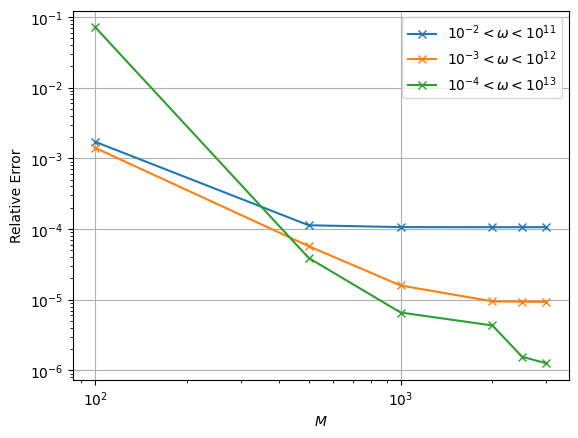

In [58]:
M=[100,500,1000,2000,2500,3000]
Err0=[0.0017086624346571116,0.00011287342007621347,0.00010635923382340262,0.00010613717325062236,0.00010613717325062236,0.00010613717325062236]
Err1=[0.0014022691719678306,5.71678229508854e-05,1.5874563461527342e-5,9.474803040393637e-06,9.3623328761472e-06,9.332448799067776e-06]
Err2=[0.07127128456610624,3.8937183364405e-05,6.582658213096477e-06,4.313868337711528e-06, 1.5594074906260396e-06,1.2577319205884529e-06]
plt.figure()
plt.loglog(M,Err0,'x-',label=r"$ 10^{-2} <  \omega < 10^{11} $")
plt.loglog(M,Err1,'x-',label=r"$ 10^{-3} <  \omega < 10^{12} $")
plt.loglog(M,Err2,'x-',label=r"$10^{-4} < \omega < 10^{13}$")
plt.legend()
plt.xlabel(r"$M$")
plt.ylabel("Relative Error")
plt.grid()
plt.savefig("results/sphere/relative_error_varyM.pdf")
plt.show()
           
           

In [ ]:
# Step response
# Get the exact td step response (Method 2)
_, A2 = exactA(time, sigma, mu, alpha, Npoles)
l_td_exact_step = A2


plt.figure(1)
scale=1.#l_td_exact_step[0]
plt.semilogx(time, l_td_exact_step /scale , 'b-', label="Exact Step")
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $-\lambda_i$, $i$="+str(i+1))

plt.legend()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$-\lambda_i/(2\pi\alpha^3)$")
#plt.title("Step")
plt.grid(True, which="both")      
plt.savefig("results/sphere/sphere_step_loglog.pdf")

plt.figure(2)
plt.semilogx(time, l_td_exact_step / scale, 'b-', label="Exact Step")
for i in range(3):
    plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $-\lambda_i$, $i$="+str(i+1))

plt.legend()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$-\lambda_i/(2\pi\alpha^3)$")
#plt.title("Step")
plt.grid(True, which="both") 
plt.savefig("results/sphere/sphere_step_semilog.pdf")

# Impulse response
# Get the exact td step response (Method 2)
_, B2 = exactB(time, sigma, mu, alpha, Npoles)
l_td_exact_impulse = B2


plt.figure(3)
scale=l_td_exact_impulse[0]
plt.loglog(time, l_td_exact_impulse / scale, 'b-', label="Exact Impulse")
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.loglog(time,Sgn_impulse[:,i]/scale,"r--",label=r"Numerical impulse, $\lambda_i$, $i$="+str(i+1))

plt.legend()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"Relative Response")
#plt.title("Impulse")
plt.grid(True, which="both")               
plt.savefig("results/sphere/sphere_impulse_loglog.pdf")

plt.figure(4)
scale=l_td_exact_impulse[0]
plt.semilogx(time, l_td_exact_impulse / scale, 'b-', label="Exact Impulse")
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,"r--",label=r"Numerical impulse, $-\lambda_i$, $i$="+str(i+1))

plt.legend()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"Relative Response")
#plt.title("Impulse")
plt.grid(True, which="both") 
plt.savefig("results/sphere/sphere_impulse_semilog.pdf")
plt.show()

